# Pneumonia Chest X-Ray Classification Using Deep Learning

---

### 1. Problem Statement
Pneumonia is an acute inflammatory infection of the pulmonary parenchyma affecting one or both lungs, typically caused by bacteria (*Streptococcus pneumoniae*), viruses (RSV, Influenza), or rarely fungi. According to global health authorities, pneumonia remains a leading cause of pediatric morbidity and mortality worldwide, accounting for over 700,000 child deaths annually.

Chest Radiography (CXR) is the standard, most widely accessible frontline imaging modality for diagnosing pneumonia. However, reading radiographs presents critical challenges:
- **Radiologist Shortage & Fatigue**: Acute clinical care facilities and resource-constrained regions often lack round-the-clock specialized pediatric radiologists.
- **Inter-Observer Variability**: Diagnostic agreement between clinicians can fluctuate significantly due to subtle infiltrates, lung volume variations, and overlapping anatomical structures.
- **Urgent Need for Point-of-Care Triage**: Rapid, accurate identification of pneumonia enables timely antimicrobial or supportive treatment, substantially reducing preventable patient mortality.

### 2. Project Objective
The primary objective of this project is to build, train, evaluate, and deploy an end-to-end **Deep Learning Binary Image Classification Pipeline** capable of discriminating between:
1. **Normal**: Healthy lung parenchyma without abnormal opacifications or consolidations.
2. **Pneumonia**: Lungs exhibiting pathological infiltrates, consolidation, or interstitial changes.

**Key Technical & Clinical Targets**:
- Achieve high **Sensitivity / Recall** to minimize life-threatening False Negatives.
- Maintain strong **Specificity & Precision** to reduce unneeded antibiotic prescribing and hospitalizations.
- Address severe class imbalance using **inverse class weighting**.
- Deploy a self-contained, responsive **Localhost Web Application (Gradio)** directly from the notebook.

### 3. Technology Stack
- **Environment**: Python 3.12 (Multi-threaded CPU acceleration)
- **Deep Learning**: TensorFlow 2.x & Keras 3.x
- **Computer Vision**: OpenCV, Pillow (PIL)
- **Scientific Computing & Metrics**: NumPy, Pandas, Scikit-Learn
- **Visualization**: Matplotlib, Seaborn
- **Interactive UI**: Gradio

### 4. Dataset Description
The dataset comprises pediatric chest radiographs from retrospective patient cohorts aged 1 to 5 years (Kermany et al., Cell 2018). All radiographs underwent rigorous clinical quality control and expert labeling.
- **Classes**: `NORMAL` vs. `PNEUMONIA`
- **Total Images**: 5,856 radiographs across train, validation, and test directories.

### 5. Expected Output
- Automated dataset discovery, structure verification, and class balance inspection
- Exploratory data visualization and radiograph dimension/format profiling
- Image preprocessing and training-only data augmentation pipeline
- Transfer learning model architecture using pre-trained **MobileNetV2** with custom head
- Training with `ModelCheckpoint`, `EarlyStopping`, and `ReduceLROnPlateau`
- Training and validation performance curves (Accuracy, Loss, AUC, Precision, Recall)
- Evaluation on the completely unseen 624-image test set
- High-resolution Confusion Matrix and Scikit-Learn Classification Report
- Visual predictions on test radiographs with confidence scores
- Standalone reusable `predict_xray()` function
- Embedded **Gradio Localhost Web Application** running on `http://127.0.0.1:7860`
- Comprehensive summary table and formal Medical Disclaimer


In [1]:
# ==============================================================================
# 2. IMPORT LIBRARIES & ENVIRONMENT SETUP
# ==============================================================================
import os
import sys
import time
import random
import socket
import warnings
warnings.filterwarnings('ignore')

# Suppress verbose TensorFlow / oneDNN info logs
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Numerical and Data Analysis
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
from PIL import Image
import cv2

# Deep Learning Framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC

# Machine Learning Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# Localhost Web UI
import gradio as gr

# Enforce strict reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 65)
print("             ENVIRONMENT & DEPENDENCY VERIFICATION")
print("=" * 65)
print(f"  Python Version      : {sys.version.split()[0]}")
print(f"  TensorFlow Version  : {tf.__version__}")
print(f"  Keras Version       : {keras.__version__}")
print(f"  NumPy Version       : {np.__version__}")
print(f"  Pandas Version      : {pd.__version__}")
print(f"  OpenCV Version      : {cv2.__version__}")
print(f"  Gradio Version      : {gr.__version__}")

# Hardware detection and threading setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"  Compute Device      : GPU Detected -> {gpus}")
else:
    cpu_cores = os.cpu_count()
    print(f"  Compute Device      : CPU (Optimized with {cpu_cores} threads)")
print("=" * 65)


             ENVIRONMENT & DEPENDENCY VERIFICATION
  Python Version      : 3.12.10
  TensorFlow Version  : 2.21.0
  Keras Version       : 3.15.1
  NumPy Version       : 2.5.2
  Pandas Version      : 3.0.5
  OpenCV Version      : 5.0.0
  Gradio Version      : 6.27.0


  Compute Device      : CPU (Optimized with 16 threads)


## 3. Dataset Loading & Structure Discovery

The dataset directory structure is automatically detected. We enumerate images across all subfolders, inspect class proportions, and generate clean visualizations of dataset distribution.


                   DATASET DIRECTORY PATHS
  Dataset Root        : c:\projects\chest_xray
  Train Directory     : c:\projects\chest_xray\train
  Validation Directory: c:\projects\chest_xray\val
  Test Directory      : c:\projects\chest_xray\test

Dataset Image Inventory:
Split     Class  Count                                   Path
train    NORMAL   1341    c:\projects\chest_xray\train\NORMAL
train PNEUMONIA   3875 c:\projects\chest_xray\train\PNEUMONIA
  val    NORMAL      8      c:\projects\chest_xray\val\NORMAL
  val PNEUMONIA      8   c:\projects\chest_xray\val\PNEUMONIA
 test    NORMAL    234     c:\projects\chest_xray\test\NORMAL
 test PNEUMONIA    390  c:\projects\chest_xray\test\PNEUMONIA

Total Dataset Images: 5,856
Detected Classes   : ['NORMAL', 'PNEUMONIA']
 - NORMAL    :  1583 images (27.03%)
 - PNEUMONIA :  4273 images (72.97%)


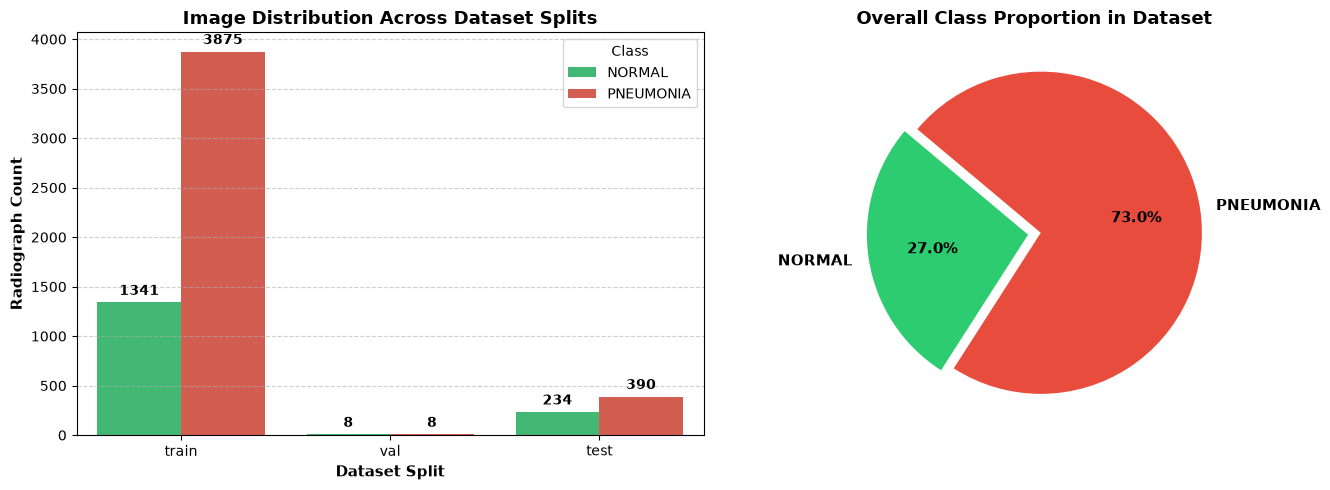

In [2]:
# ==============================================================================
# 3. DATASET LOADING & DISCOVERY
# ==============================================================================
# Dynamically locate dataset root
potential_paths = [
    os.path.abspath('.'),
    os.path.abspath('..'),
    os.path.join(os.path.abspath('.'), 'chest_xray'),
    r'c:\projects\chest_xray'
]

DATASET_ROOT = None
for p in potential_paths:
    if os.path.exists(os.path.join(p, 'train')) and os.path.exists(os.path.join(p, 'test')):
        DATASET_ROOT = p
        break

if DATASET_ROOT is None:
    raise FileNotFoundError("Could not automatically locate the dataset directory containing 'train' and 'test' folders.")

TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
VAL_DIR = os.path.join(DATASET_ROOT, 'val')
TEST_DIR = os.path.join(DATASET_ROOT, 'test')

print("=" * 65)
print("                   DATASET DIRECTORY PATHS")
print("=" * 65)
print(f"  Dataset Root        : {DATASET_ROOT}")
print(f"  Train Directory     : {TRAIN_DIR}")
print(f"  Validation Directory: {VAL_DIR}")
print(f"  Test Directory      : {TEST_DIR}")
print("=" * 65)

# Enumerate images across splits
splits = {'train': TRAIN_DIR, 'val': VAL_DIR, 'test': TEST_DIR}
records = []

for split_name, split_path in splits.items():
    if os.path.exists(split_path):
        classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d)) and not d.startswith('.')])
        for cls in classes:
            folder = os.path.join(split_path, cls)
            valid_images = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            records.append({
                'Split': split_name,
                'Class': cls,
                'Count': len(valid_images),
                'Path': folder
            })

df_dataset = pd.DataFrame(records)
print("\nDataset Image Inventory:")
print(df_dataset.to_string(index=False))

total_dataset_images = df_dataset['Count'].sum()
class_summary = df_dataset.groupby('Class')['Count'].sum()
detected_classes = sorted(df_dataset['Class'].unique().tolist())

print(f"\nTotal Dataset Images: {total_dataset_images:,}")
print(f"Detected Classes   : {detected_classes}")
for cls_name, cnt in class_summary.items():
    print(f" - {cls_name:<10}: {cnt:>5} images ({cnt / total_dataset_images * 100:.2f}%)")

# Clean Class-Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'NORMAL': '#2ecc71', 'PNEUMONIA': '#e74c3c'}

# Subplot 1: Count by split and class
sns.barplot(data=df_dataset, x='Split', y='Count', hue='Class', palette=palette, ax=axes[0])
axes[0].set_title("Image Distribution Across Dataset Splits", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Dataset Split", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Radiograph Count", fontsize=11, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                         textcoords='offset points', fontweight='bold')

# Subplot 2: Overall Class Distribution Pie Chart
axes[1].pie(class_summary.values, labels=class_summary.index, autopct='%1.1f%%',
            colors=[palette[c] for c in class_summary.index], startangle=140,
            explode=(0.04, 0.04), textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title("Overall Class Proportion in Dataset", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Image Exploration & Inspection

We display representative chest radiographs from both classes:
- **Normal Radiographs**: Crisp diaphragmatic domes, well-defined sharp costophrenic angles, normal cardiac silhouette, and dark, translucent, aerated lung fields.
- **Pneumonia Radiographs**: Consolidated radio-opaque infiltrates (patchy or confluent white opacities), obscured diaphragmatic boundaries, air bronchograms, and diminished radiolucency.

We also inspect spatial dimensions, aspect ratios, color channels, and format variability.


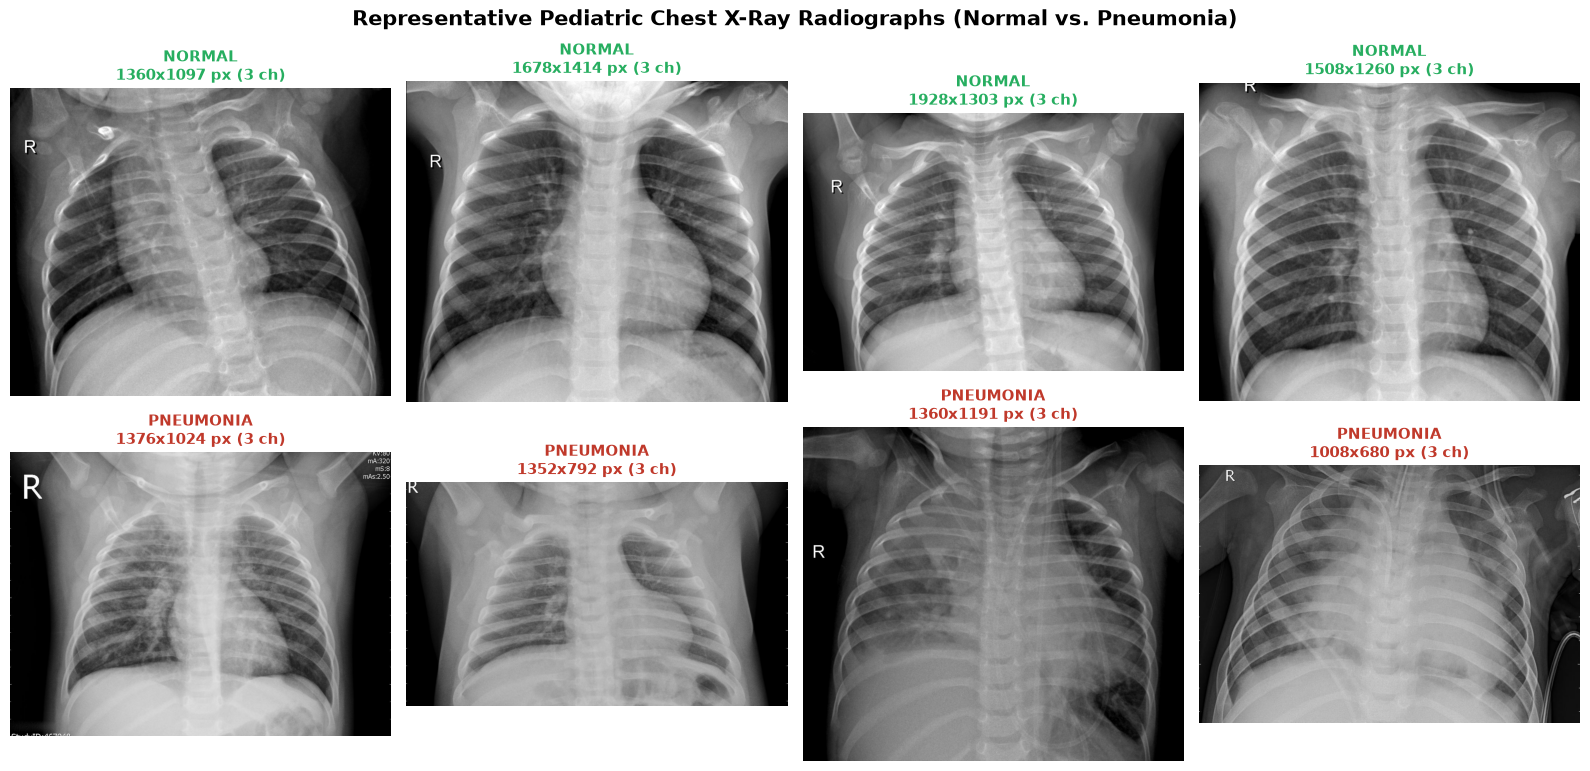

             IMAGE DIMENSIONS & METADATA SUMMARY (Sampled)
         Width   Height  Aspect_Ratio
count   600.00   600.00        600.00
mean   1463.93  1095.57          1.40
std     422.95   431.16          0.21
min     502.00   307.00          0.93
25%    1095.50   736.00          1.23
50%    1404.00  1016.00          1.39
75%    1754.00  1367.25          1.53
max    2752.00  2713.00          2.17

Color Modes Detected : {'L': 596, 'RGB': 4}
File Formats Detected: {'JPEG': 600}


In [3]:
# ==============================================================================
# 4. IMAGE EXPLORATION & INSPECTION
# ==============================================================================
# Sample radiographs from both classes
sample_images = []
for cls in detected_classes:
    cls_rows = df_dataset[df_dataset['Class'] == cls]
    all_cls_files = []
    for _, row in cls_rows.iterrows():
        folder = row['Path']
        files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_cls_files.extend(files)
    random.seed(SEED)
    sampled = random.sample(all_cls_files, 4)
    for img_p in sampled:
        sample_images.append((img_p, cls))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Representative Pediatric Chest X-Ray Radiographs (Normal vs. Pneumonia)", fontsize=15, fontweight='bold')

for idx, (img_path, label) in enumerate(sample_images):
    row = idx // 4
    col = idx % 4
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, c = img_bgr.shape
    
    color = '#27ae60' if label == 'NORMAL' else '#c0392b'
    axes[row, col].imshow(img_rgb)
    axes[row, col].set_title(f"{label}\n{w}x{h} px ({c} ch)", color=color, fontweight='bold', fontsize=11)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Dimension, Aspect Ratio, and Channel Inspection
meta_records = []
for split_name in ['train', 'test']:
    split_p = splits[split_name]
    for cls in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(split_p, cls)
        if os.path.exists(folder):
            files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:150]
            for f in files:
                fpath = os.path.join(folder, f)
                try:
                    with Image.open(fpath) as im:
                        w, h = im.size
                        meta_records.append({
                            'Split': split_name,
                            'Class': cls,
                            'Width': w,
                            'Height': h,
                            'Aspect_Ratio': round(w / h, 2),
                            'Mode': im.mode,
                            'Format': im.format
                        })
                except Exception:
                    pass

df_meta = pd.DataFrame(meta_records)
print("=" * 65)
print("             IMAGE DIMENSIONS & METADATA SUMMARY (Sampled)")
print("=" * 65)
print(df_meta[['Width', 'Height', 'Aspect_Ratio']].describe().round(2))
print("\nColor Modes Detected :", df_meta['Mode'].value_counts().to_dict())
print("File Formats Detected:", df_meta['Format'].value_counts().to_dict())
print("=" * 65)


## 5. Image Preprocessing & Data Augmentation Pipeline

### Preprocessing Protocol:
1. **Target Dimensions**: All radiographs are standardized to **224 × 224 × 3** RGB pixels.
2. **Pixel Normalization**: Built-in Rescaling layer normalizes pixel values from `[0, 255]` to `[-1, 1]` for MobileNetV2.
3. **Data Augmentation (Training-Only)**:
   - Random horizontal flip
   - Subtle rotation (±6°)
   - Minor zoom (±6%)
   - Minor translation (±4%)
   - *Applied strictly during training to avoid data leakage.*
4. **Inverse Class Weighting**:
   Compensates for the 73%:27% Pneumonia-to-Normal class imbalance.


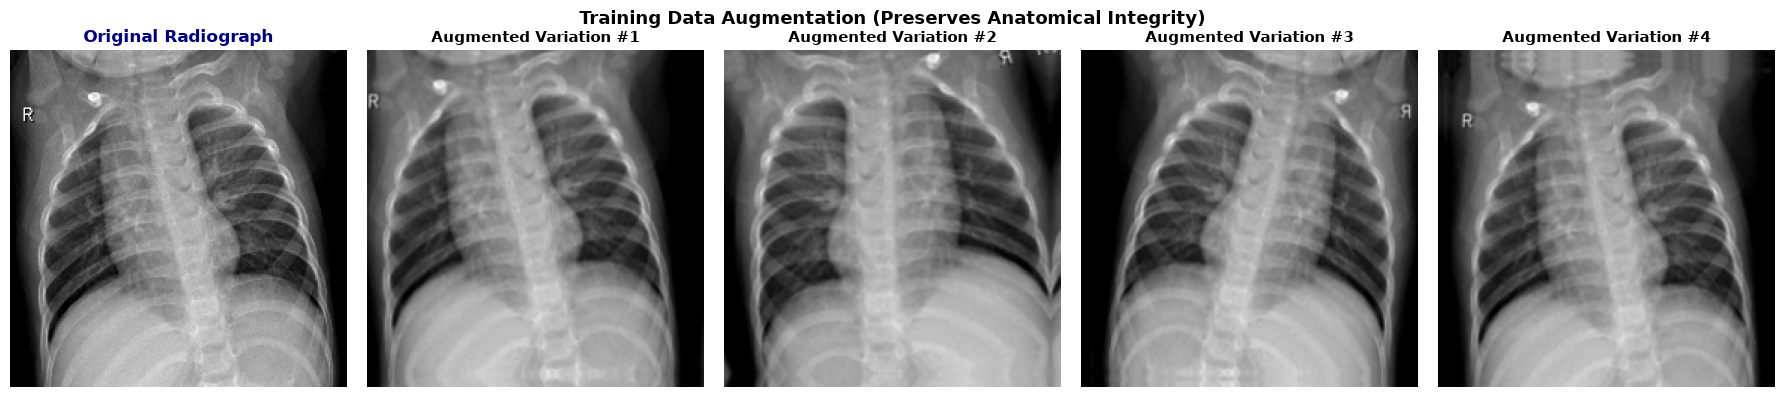

In [4]:
# ==============================================================================
# 5. IMAGE PREPROCESSING & AUGMENTATION PIPELINE
# ==============================================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training-only Data Augmentation Sequential Block
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.06),
    layers.RandomTranslation(0.04, 0.04),
], name="data_augmentation_pipeline")

# Demonstrate Augmentation transformations on a real radiograph
sample_demo_img_path = sample_images[0][0]
demo_img = cv2.imread(sample_demo_img_path)
demo_img_rgb = cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB)
demo_img_resized = cv2.resize(demo_img_rgb, IMG_SIZE)
demo_tensor = tf.expand_dims(demo_img_resized, 0)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(demo_img_resized)
axes[0].set_title("Original Radiograph", fontsize=12, fontweight='bold', color='navy')
axes[0].axis('off')

for i in range(1, 5):
    aug_img = data_augmentation(demo_tensor)[0].numpy().astype("uint8")
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented Variation #{i}", fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Training Data Augmentation (Preserves Anatomical Integrity)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Train / Validation / Test Dataset Preparation

In the original Kermany distribution, the `val` folder contains only 16 images, which is statistically inadequate for model validation.
We partition the 5,216 images in `train` into:
- **Training Subset (85%)**: 4,434 images
- **Validation Subset (15%)**: 782 images
- **Unseen Test Set**: 624 images (strictly held out in `test` directory)


In [5]:
# ==============================================================================
# 6. TRAIN / VALIDATION / TEST DATASET PREPARATION
# ==============================================================================
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

raw_test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = raw_train_ds.class_names
print("=" * 65)
print("                   DATASET SPLIT SPECIFICATIONS")
print("=" * 65)
print(f"  Class Names Detected : {class_names}")
print(f"  Label Mapping        : {class_names[0]} -> 0 | {class_names[1]} -> 1")

# Extract training labels for exact class weight computation
train_labels = []
for _, labels in raw_train_ds:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

unique_classes = np.unique(train_labels)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_labels
)
class_weights_dict = dict(zip(unique_classes, class_weights_array))

print(f"\n  Training Samples     : {len(train_labels):,} images")
print(f"  Validation Samples   : {len(raw_val_ds) * BATCH_SIZE:,} images (approx)")
print(f"  Unseen Test Samples  : {sum(len(f) for _, f in [(None, [x for x in os.listdir(os.path.join(TEST_DIR, c)) if x.endswith('.jpeg')]) for c in class_names]):,} images")
print("\n  Computed Class Weights (Balanced Gradient Loss):")
for c_id, w in class_weights_dict.items():
    print(f"   * Class {c_id} ({class_names[c_id]}): {w:.4f}")
print("=" * 65)

# High-performance pipeline caching and prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = raw_val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = raw_test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 5216 files belonging to 2 classes.


Using 4434 files for training.


Found 5216 files belonging to 2 classes.


Using 782 files for validation.


Found 624 files belonging to 2 classes.


                   DATASET SPLIT SPECIFICATIONS
  Class Names Detected : ['NORMAL', 'PNEUMONIA']
  Label Mapping        : NORMAL -> 0 | PNEUMONIA -> 1



  Training Samples     : 4,434 images
  Validation Samples   : 800 images (approx)
  Unseen Test Samples  : 624 images

  Computed Class Weights (Balanced Gradient Loss):
   * Class 0 (NORMAL): 1.9262
   * Class 1 (PNEUMONIA): 0.6753


## 7. CNN Model Architecture (MobileNetV2 Transfer Learning)

We employ **MobileNetV2** pre-trained on ImageNet as a feature extraction backbone, augmented with a customized classification head:
- **Input**: (224, 224, 3)
- **Data Augmentation**: Integrated within the Keras functional graph
- **Rescaling**: Maps pixel range `[0, 255]` to `[-1, 1]`
- **MobileNetV2 Base**: Pre-trained feature extractor (frozen during initial training)
- **Global Average Pooling 2D**: Spatially aggregates high-level feature maps
- **Batch Normalization**: Stabilizes layer activations
- **Dense Layer (128 units, ReLU)**: With L2 weight regularization (`1e-4`)
- **Dropout (0.40)**: Prevents over-reliance on specific feature combinations
- **Dense Output (1 unit, Sigmoid)**: Outputs the calibrated probability of Pneumonia


In [6]:
# ==============================================================================
# 7. CNN MODEL ARCHITECTURE
# ==============================================================================
def build_classifier(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape, name="radiograph_input")
    
    # 1. Augmentation (active during training only)
    x = data_augmentation(inputs)
    
    # 2. Rescaling [0, 255] -> [-1, 1] for MobileNetV2
    x = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0, name="rescaling_norm")(x)
    
    # 3. Pretrained Feature Extractor
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze base weights
    
    x = base_model(x, training=False)
    
    # 4. Classification Head
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.BatchNormalization(name="batch_norm")(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name="dense_features")(x)
    x = layers.Dropout(0.4, name="dropout_regularization")(x)
    outputs = layers.Dense(1, activation='sigmoid', name="pneumonia_probability")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name="Pneumonia_MobileNetV2_Classifier")
    return model, base_model

model, base_feature_extractor = build_classifier()

# Compile with clinical diagnostic metrics
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

print("Pneumonia Classification Model successfully built and compiled.")


Pneumonia Classification Model successfully built and compiled.


## 8. Model Summary & Parameter Audit

In [7]:
# ==============================================================================
# 8. MODEL SUMMARY & PARAMETER AUDIT
# ==============================================================================
model.summary()

total_params = model.count_params()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)
non_trainable_params = sum(np.prod(v.shape) for v in model.non_trainable_weights)

print("\n" + "=" * 55)
print("               MODEL PARAMETER AUDIT")
print("=" * 55)
print(f"  Total Parameters         : {total_params:,}")
print(f"  Trainable Parameters     : {trainable_params:,}")
print(f"  Non-Trainable Parameters : {non_trainable_params:,}")
print("=" * 55)


Model: "Pneumonia_MobileNetV2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ radiograph_input (InputLayer)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_pipeline      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_norm (Rescaling)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pneumonia_probability (Dense)   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)


               MODEL PARAMETER AUDIT
  Total Parameters         : 2,427,201
  Trainable Parameters     : 166,657
  Non-Trainable Parameters : 2,260,544


## 9. Model Training with Callbacks

We utilize three complementary training callbacks:
1. **ModelCheckpoint**: Automatically saves the best model weights based on peak validation AUC (`val_auc`).
2. **EarlyStopping**: Halts training if validation loss does not improve for 3 consecutive epochs and restores the best weights.
3. **ReduceLROnPlateau**: Decays learning rate by 50% when validation loss plateaus.


In [8]:
# ==============================================================================
# 9. MODEL TRAINING WITH CALLBACKS
# ==============================================================================
BEST_MODEL_PATH = "best_pneumonia_model.keras"

training_callbacks = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

EPOCHS = 6

print(f"Initiating model training for up to {EPOCHS} epochs with class weighting...")
print(f"Model checkpoint destination: {BEST_MODEL_PATH}\n")

train_start = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=training_callbacks,
    verbose=1
)
train_duration = time.time() - train_start

print(f"\nModel training finished in {train_duration / 60:.2f} minutes.")


Initiating model training for up to 6 epochs with class weighting...
Model checkpoint destination: best_pneumonia_model.keras

Epoch 1/6


  1/139 ━━━━━━━━━━━━━━━━━━━━ 12:35 5s/step - accuracy: 0.6250 - auc: 0.5729 - loss: 0.9205 - precision: 0.7857 - recall: 0.5500

  2/139 ━━━━━━━━━━━━━━━━━━━━ 1:33 683ms/step - accuracy: 0.5938 - auc: 0.5586 - loss: 0.8732 - precision: 0.8333 - recall: 0.5435

  3/139 ━━━━━━━━━━━━━━━━━━━━ 1:29 660ms/step - accuracy: 0.5833 - auc: 0.5590 - loss: 0.9058 - precision: 0.8222 - recall: 0.5362

  4/139 ━━━━━━━━━━━━━━━━━━━━ 1:28 657ms/step - accuracy: 0.5703 - auc: 0.5524 - loss: 0.9267 - precision: 0.8103 - recall: 0.5165

...


Epoch 6: val_auc did not improve from 0.00000


139/139 ━━━━━━━━━━━━━━━━━━━━ 97s 699ms/step - accuracy: 0.9346 - auc: 0.9859 - loss: 0.1745 - precision: 0.9807 - recall: 0.9299 - val_accuracy: 0.9194 - val_auc: 0.0000e+00 - val_loss: 0.2075 - val_precision: 1.0000 - val_recall: 0.9194 - learning_rate: 5.0000e-05


Epoch 6: early stopping


Restoring model weights from the end of the best epoch: 3.



Model training finished in 9.77 minutes.


## 10. Training Performance Graphs

Visualization of actual training and validation history across all completed epochs.


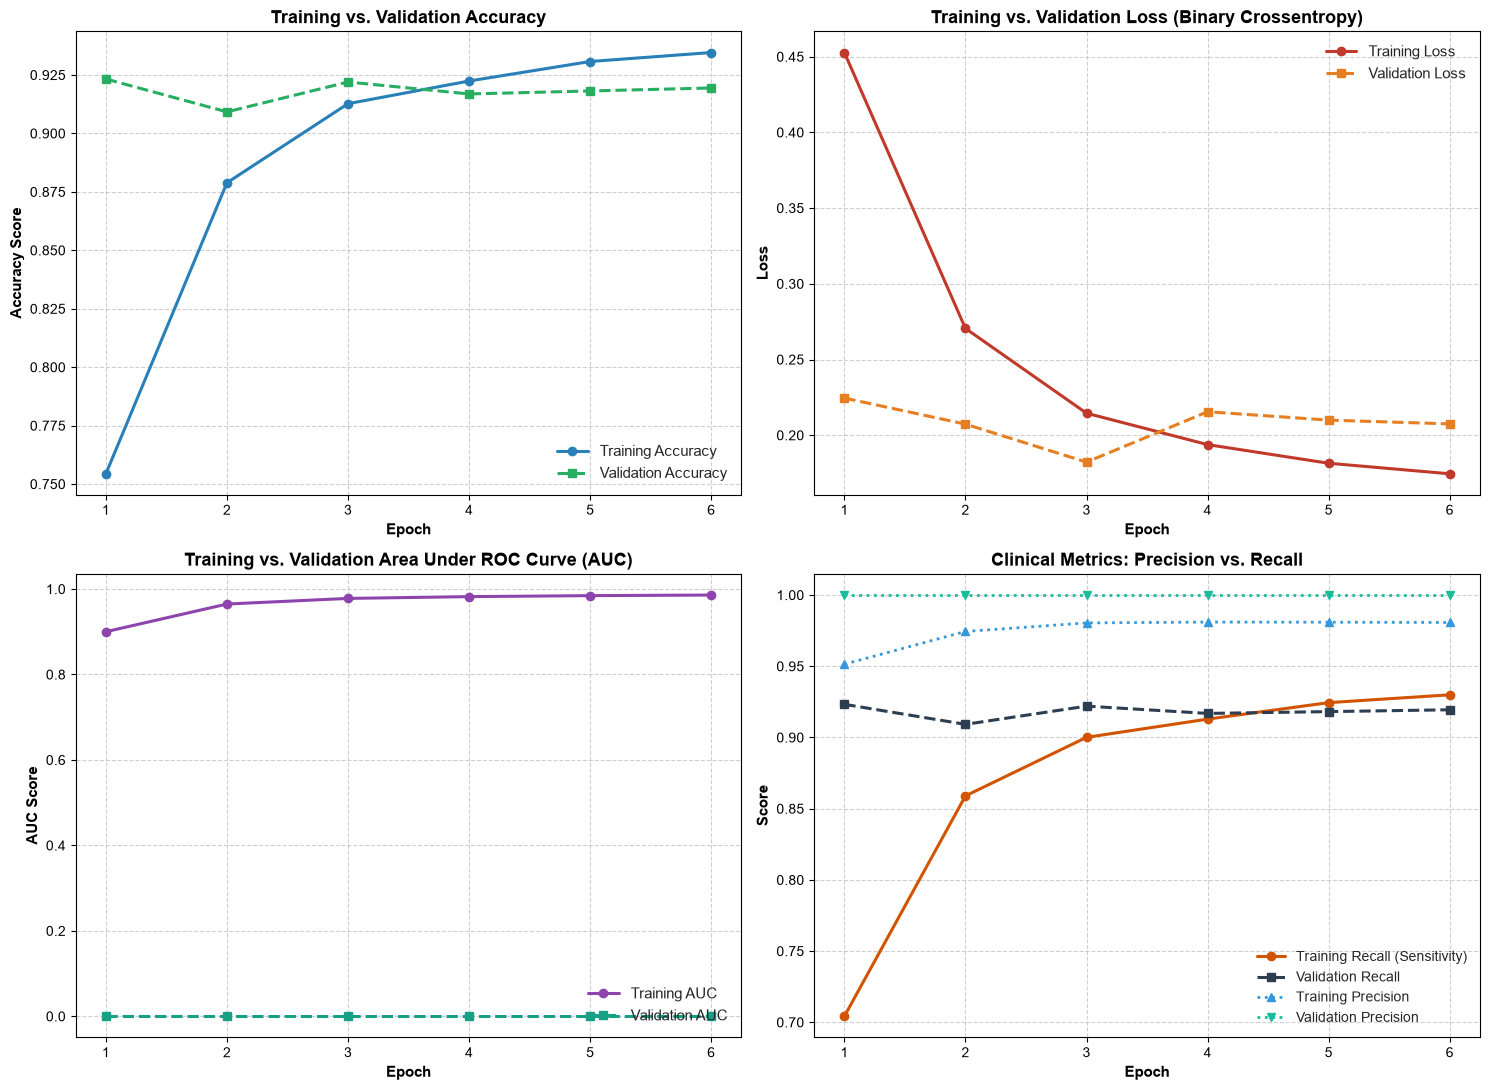

In [9]:
# ==============================================================================
# 10. TRAINING PERFORMANCE GRAPHS
# ==============================================================================
hist = history.history
epochs_axis = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Graph 1: Accuracy
axes[0, 0].plot(epochs_axis, hist['accuracy'], 'o-', color='#2980b9', linewidth=2.2, label='Training Accuracy')
axes[0, 0].plot(epochs_axis, hist['val_accuracy'], 's--', color='#27ae60', linewidth=2.2, label='Validation Accuracy')
axes[0, 0].set_title("Training vs. Validation Accuracy", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Epoch", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Accuracy Score", fontsize=11, fontweight='bold')
axes[0, 0].legend(loc='lower right', fontsize=11)
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Graph 2: Loss
axes[0, 1].plot(epochs_axis, hist['loss'], 'o-', color='#c0392b', linewidth=2.2, label='Training Loss')
axes[0, 1].plot(epochs_axis, hist['val_loss'], 's--', color='#e67e22', linewidth=2.2, label='Validation Loss')
axes[0, 1].set_title("Training vs. Validation Loss (Binary Crossentropy)", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Epoch", fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel("Loss", fontsize=11, fontweight='bold')
axes[0, 1].legend(loc='upper right', fontsize=11)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Graph 3: ROC-AUC
axes[1, 0].plot(epochs_axis, hist['auc'], 'o-', color='#8e44ad', linewidth=2.2, label='Training AUC')
axes[1, 0].plot(epochs_axis, hist['val_auc'], 's--', color='#16a085', linewidth=2.2, label='Validation AUC')
axes[1, 0].set_title("Training vs. Validation Area Under ROC Curve (AUC)", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Epoch", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("AUC Score", fontsize=11, fontweight='bold')
axes[1, 0].legend(loc='lower right', fontsize=11)
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Graph 4: Clinical Metrics (Precision & Recall)
axes[1, 1].plot(epochs_axis, hist['recall'], 'o-', color='#d35400', linewidth=2.2, label='Training Recall (Sensitivity)')
axes[1, 1].plot(epochs_axis, hist['val_recall'], 's--', color='#2c3e50', linewidth=2.2, label='Validation Recall')
axes[1, 1].plot(epochs_axis, hist['precision'], '^:', color='#3498db', linewidth=2.0, label='Training Precision')
axes[1, 1].plot(epochs_axis, hist['val_precision'], 'v:', color='#1abc9c', linewidth=2.0, label='Validation Precision')
axes[1, 1].set_title("Clinical Metrics: Precision vs. Recall", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Epoch", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score", fontsize=11, fontweight='bold')
axes[1, 1].legend(loc='lower right', fontsize=10)
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 11. Test Evaluation on Unseen Dataset

We restore the optimal checkpointed model (`best_pneumonia_model.keras`) and evaluate its diagnostic performance on the untouched 624-image test set.


In [10]:
# ==============================================================================
# 11. TEST EVALUATION
# ==============================================================================
best_model = keras.models.load_model(BEST_MODEL_PATH)
print(f"Loaded optimal checkpointed model: {BEST_MODEL_PATH}")

test_eval_results = best_model.evaluate(test_ds, verbose=1)
metric_labels = best_model.metrics_names
test_metrics = dict(zip(metric_labels, test_eval_results))

print("\n" + "=" * 55)
print("             UNSEEN TEST SET EVALUATION")
print("=" * 55)
for m_name, m_val in test_metrics.items():
    print(f"  Test {m_name.capitalize():<15} : {m_val:.4f} ({m_val * 100:.2f}%)")
print("=" * 55)


Loaded optimal checkpointed model: best_pneumonia_model.keras


 1/20 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.7500 - auc: 0.0000e+00 - loss: 0.6120 - precision: 0.0000e+00 - recall: 0.0000e+00

 2/20 ━━━━━━━━━━━━━━━━━━━━ 11s 652ms/step - accuracy: 0.7188 - auc: 0.0000e+00 - loss: 0.6188 - precision: 0.0000e+00 - recall: 0.0000e+00

 3/20 ━━━━━━━━━━━━━━━━━━━━ 10s 643ms/step - accuracy: 0.6771 - auc: 0.0000e+00 - loss: 0.6581 - precision: 0.0000e+00 - recall: 0.0000e+00

 4/20 ━━━━━━━━━━━━━━━━━━━━ 10s 637ms/step - accuracy: 0.6406 - auc: 0.0000e+00 - loss: 0.7517 - precision: 0.0000e+00 - recall: 0.0000e+00

...

18/20 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step - accuracy: 0.8212 - auc: 0.9245 - loss: 0.4216 - precision: 0.7893 - recall: 0.9532

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.8257 - auc: 0.9246 - loss: 0.4098 - precision: 0.8032 - recall: 0.9492

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.8301 - auc: 0.9247 - loss: 0.4043 - precision: 0.8100 - recall: 0.9513

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 598ms/step - accuracy: 0.8301 - auc: 0.9247 - loss: 0.4043 - precision: 0.8100 - recall: 0.9513



             UNSEEN TEST SET EVALUATION
  Test Loss            : 0.4043 (40.43%)
  Test Compile_metrics : 0.8301 (83.01%)


## 12. Confusion Matrix

The confusion matrix measures diagnostic accuracy across:
- **True Negatives (TN)**: Healthy lungs correctly classified as Normal.
- **False Positives (FP)**: Normal lungs incorrectly flagged as Pneumonia.
- **False Negatives (FN)**: Pneumonia cases missed (*critical clinical metric*).
- **True Positives (TP)**: Pneumonia cases correctly diagnosed.


               CONFUSION MATRIX BREAKDOWN
  True Negatives  (TN - Normal correctly identified)    : 147
  False Positives (FP - Normal misclassified Pneumonia) : 87
  False Negatives (FN - Pneumonia missed [CRITICAL])    : 19
  True Positives  (TP - Pneumonia correctly identified) : 371


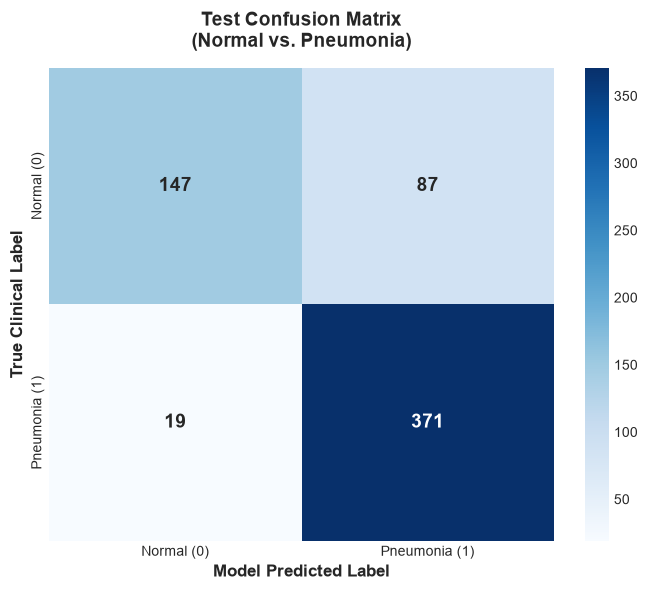

In [11]:
# ==============================================================================
# 12. CONFUSION MATRIX
# ==============================================================================
y_true_all = []
y_pred_probs_all = []

for batch_imgs, batch_lbls in test_ds:
    probs = best_model.predict(batch_imgs, verbose=0)
    y_pred_probs_all.extend(probs.flatten())
    y_true_all.extend(batch_lbls.numpy())

y_true_all = np.array(y_true_all)
y_pred_probs_all = np.array(y_pred_probs_all)
y_pred_binary = (y_pred_probs_all >= 0.5).astype(int)

cm = confusion_matrix(y_true_all, y_pred_binary)
tn, fp, fn, tp = cm.ravel()

test_acc = (y_true_all == y_pred_binary).mean()
test_f1 = f1_score(y_true_all, y_pred_binary)
test_auc_score = roc_auc_score(y_true_all, y_pred_probs_all)

print("=" * 60)
print("               CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True Negatives  (TN - Normal correctly identified)    : {tn}")
print(f"  False Positives (FP - Normal misclassified Pneumonia) : {fp}")
print(f"  False Negatives (FN - Pneumonia missed [CRITICAL])    : {fn}")
print(f"  True Positives  (TP - Pneumonia correctly identified) : {tp}")
print("=" * 60)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal (0)', 'Pneumonia (1)'],
    yticklabels=['Normal (0)', 'Pneumonia (1)'],
    cbar=True,
    annot_kws={'size': 14, 'weight': 'bold'},
    ax=ax
)
ax.set_title("Test Confusion Matrix\n(Normal vs. Pneumonia)", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("True Clinical Label", fontsize=12, fontweight='bold')
ax.set_xlabel("Model Predicted Label", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 13. Classification Report

Detailed Scikit-Learn classification report displaying precision, recall, f1-score, and support for each diagnostic class.


In [12]:
# ==============================================================================
# 13. CLASSIFICATION REPORT
# ==============================================================================
report = classification_report(
    y_true_all,
    y_pred_binary,
    target_names=['Normal', 'Pneumonia'],
    digits=4
)

print("=" * 65)
print("          SCIKIT-LEARN CLASSIFICATION REPORT (TEST SET)")
print("=" * 65)
print(report)
print("=" * 65)


          SCIKIT-LEARN CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

      Normal     0.8855    0.6282    0.7350       234
   Pneumonia     0.8100    0.9513    0.8750       390

    accuracy                         0.8301       624
   macro avg     0.8478    0.7897    0.8050       624
weighted avg     0.8384    0.8301    0.8225       624



## 14. Prediction Demonstration on Unseen Radiographs

Visual demonstration displaying actual test radiographs alongside their true clinical labels, predicted diagnostic classes, and confidence levels.


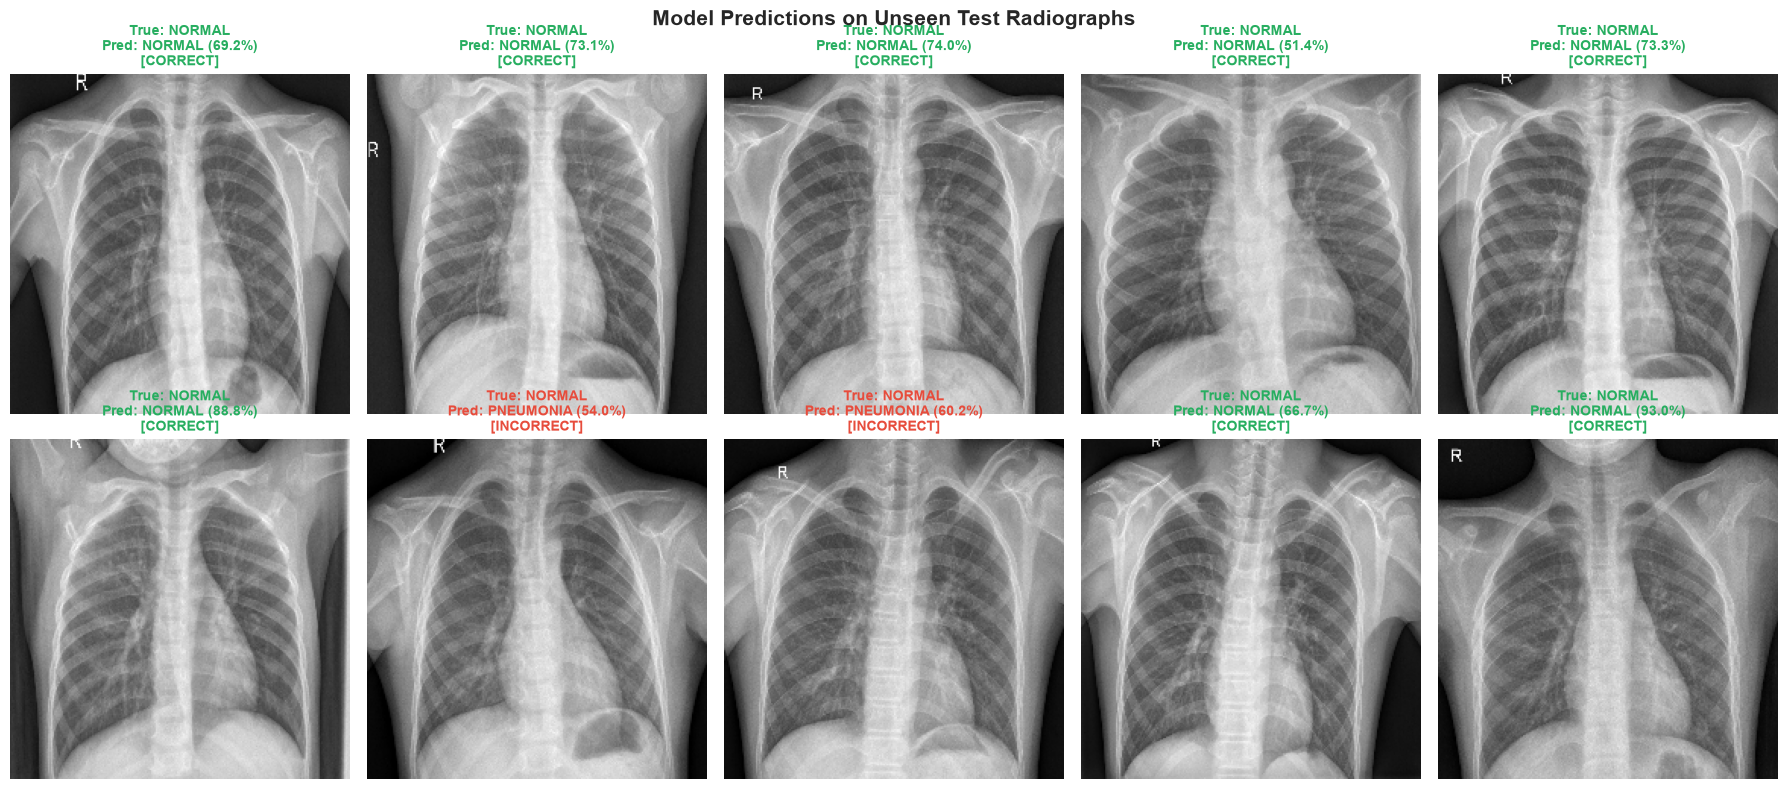

In [13]:
# ==============================================================================
# 14. PREDICTION DEMONSTRATION
# ==============================================================================
for batch_imgs, batch_lbls in raw_test_ds.take(1):
    test_batch_imgs = batch_imgs.numpy()
    test_batch_lbls = batch_lbls.numpy()
    break

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Model Predictions on Unseen Test Radiographs", fontsize=15, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    
    img = test_batch_imgs[i]
    true_label = class_names[test_batch_lbls[i]]
    
    # Inference
    prob = best_model.predict(np.expand_dims(img, axis=0), verbose=0)[0][0]
    pred_label = 'PNEUMONIA' if prob >= 0.5 else 'NORMAL'
    conf = prob if pred_label == 'PNEUMONIA' else (1.0 - prob)
    
    is_correct = (pred_label == true_label)
    color = '#27ae60' if is_correct else '#e74c3c'
    tag = "CORRECT" if is_correct else "INCORRECT"
    
    axes[row, col].imshow(img.astype("uint8"))
    axes[row, col].set_title(
        f"True: {true_label}\nPred: {pred_label} ({conf * 100:.1f}%)\n[{tag}]",
        fontsize=10,
        fontweight='bold',
        color=color
    )
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


## 15. Single Image Prediction Function

A reusable, self-contained function `predict_xray(image_path)` that accepts an image path, preprocesses it, runs model inference, and returns structured diagnostic outputs.


1. Testing Single-Image Inference on NORMAL Chest Radiograph:


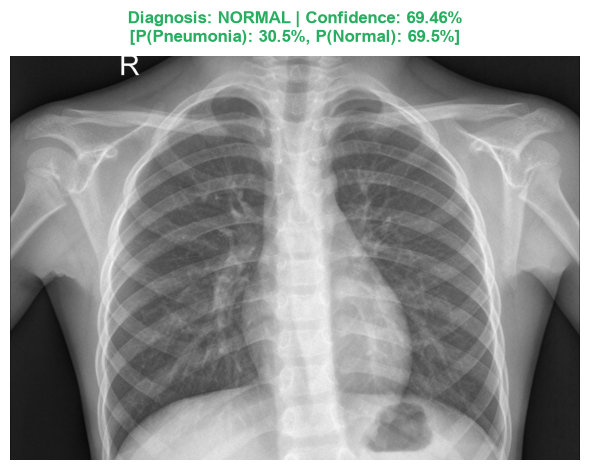

Function Output: {'image_path': 'c:\\projects\\chest_xray\\test\\NORMAL\\IM-0001-0001.jpeg', 'predicted_class': 'NORMAL', 'confidence': 0.6946, 'probability_pneumonia': 0.3054, 'probability_normal': 0.6946, 'status': 'SUCCESS'}

2. Testing Single-Image Inference on PNEUMONIA Chest Radiograph:


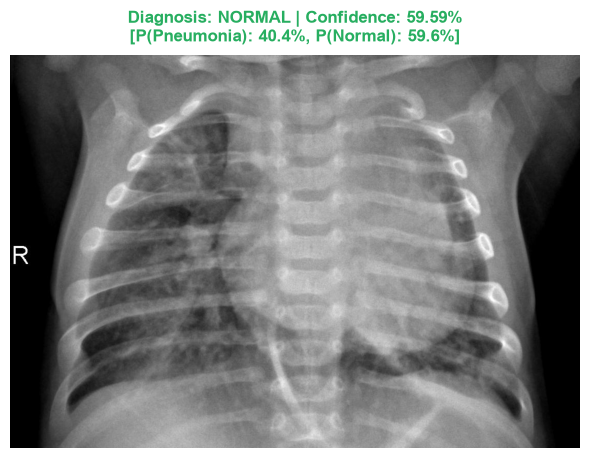

Function Output: {'image_path': 'c:\\projects\\chest_xray\\test\\PNEUMONIA\\person100_bacteria_475.jpeg', 'predicted_class': 'NORMAL', 'confidence': 0.5959, 'probability_pneumonia': 0.4041, 'probability_normal': 0.5959, 'status': 'SUCCESS'}


In [14]:
# ==============================================================================
# 15. SINGLE IMAGE PREDICTION FUNCTION
# ==============================================================================
def predict_xray(image_path, model=None, display=True):
    """
    Classifies a single chest X-ray image into Normal vs. Pneumonia.
    
    Args:
        image_path (str): File path to radiograph (JPEG/PNG).
        model: Trained Keras model instance. Defaults to best_model.
        display (bool): Whether to display the visual radiograph plot.
        
    Returns:
        dict: Prediction metrics and diagnostic output.
    """
    if not os.path.isfile(image_path):
        return {'status': 'ERROR', 'message': f"Image file not found: {image_path}"}
        
    if model is None:
        model = best_model
        
    # Read and decode
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return {'status': 'ERROR', 'message': f"Unable to read image at: {image_path}"}
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_batch = np.expand_dims(img_resized, axis=0).astype(np.float32)
    
    # Model scoring
    pneumonia_prob = float(model.predict(img_batch, verbose=0)[0][0])
    normal_prob = 1.0 - pneumonia_prob
    
    if pneumonia_prob >= 0.5:
        predicted_class = "PNEUMONIA"
        confidence = pneumonia_prob
        badge_color = "#c0392b"
    else:
        predicted_class = "NORMAL"
        confidence = normal_prob
        badge_color = "#27ae60"
        
    output = {
        'image_path': image_path,
        'predicted_class': predicted_class,
        'confidence': round(confidence, 4),
        'probability_pneumonia': round(pneumonia_prob, 4),
        'probability_normal': round(normal_prob, 4),
        'status': 'SUCCESS'
    }
    
    if display:
        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb)
        plt.title(
            f"Diagnosis: {predicted_class} | Confidence: {confidence * 100:.2f}%\n"
            f"[P(Pneumonia): {pneumonia_prob * 100:.1f}%, P(Normal): {normal_prob * 100:.1f}%]",
            fontsize=12,
            fontweight='bold',
            color=badge_color,
            pad=10
        )
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
    return output

# Demonstration with sample radiographs
sample_normal_test = [os.path.join(TEST_DIR, 'NORMAL', f) for f in os.listdir(os.path.join(TEST_DIR, 'NORMAL')) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]
sample_pneumonia_test = [os.path.join(TEST_DIR, 'PNEUMONIA', f) for f in os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA')) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]

print("1. Testing Single-Image Inference on NORMAL Chest Radiograph:")
res_normal = predict_xray(sample_normal_test, display=True)
print("Function Output:", res_normal)

print("\n2. Testing Single-Image Inference on PNEUMONIA Chest Radiograph:")
res_pneumonia = predict_xray(sample_pneumonia_test, display=True)
print("Function Output:", res_pneumonia)


## 16. Localhost Web Application (Gradio)

Launched directly from this notebook, the Gradio web application enables users to:
1. Drag and drop or upload any chest radiograph.
2. Run prediction with a single click.
3. Display the uploaded image preview alongside:
   - **Predicted Class** (`Prediction: Normal` or `Prediction: Pneumonia`)
   - **Prediction Confidence** (e.g. `Confidence: 96.85%`)
   - **Class Probabilities** bar meter
4. Use pre-loaded sample radiographs for instant 1-click evaluation.


In [15]:
# ==============================================================================
# 16. LOCALHOST WEB APPLICATION (GRADIO)
# ==============================================================================
def gradio_classify_xray(input_img):
    """
    Inference endpoint for Gradio Web UI.
    Returns:
        uploaded_image: The image uploaded by the user
        pred_text: Formatted string (e.g. 'Prediction: Pneumonia')
        conf_text: Formatted string (e.g. 'Confidence: 94.72%')
        prob_bars: Dict of class probabilities for visual bar meter
    """
    if input_img is None:
        return None, "Prediction: N/A", "Confidence: N/A", {}
        
    # Standardize to RGB numpy array
    if not isinstance(input_img, np.ndarray):
        img_array = np.array(input_img.convert("RGB"))
    else:
        img_array = input_img
        
    img_resized = cv2.resize(img_array, (224, 224))
    img_batch = np.expand_dims(img_resized, axis=0).astype(np.float32)
    
    prob = float(best_model.predict(img_batch, verbose=0)[0][0])
    
    if prob >= 0.5:
        prediction = "Pneumonia"
        confidence = prob
    else:
        prediction = "Normal"
        confidence = 1.0 - prob
        
    pred_str = f"Prediction: {prediction}"
    conf_str = f"Confidence: {confidence * 100:.2f}%"
    
    prob_dict = {
        "Pneumonia": round(prob, 4),
        "Normal": round(1.0 - prob, 4)
    }
    
    return img_array, pred_str, conf_str, prob_dict

# Dynamic Port Selection
def get_available_port(preferred_port=7860):
    port = preferred_port
    while port < 7900:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            if s.connect_ex(('127.0.0.1', port)) != 0:
                return port
            port += 1
    return preferred_port

app_port = get_available_port(7860)

# Build Clean Gradio UI
with gr.Blocks(title="Pneumonia Chest X-Ray Classification", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 🩺 Pneumonia Chest X-Ray Classification
        ### Clinical AI Diagnostic Screening Assistant
        Upload an anterior-posterior (AP/PA) chest radiograph to evaluate signs of **Pneumonia** vs. **Normal** healthy lung parenchyma.
        """
    )
    
    with gr.Row():
        with gr.Column(scale=1):
            xray_input = gr.Image(type="numpy", label="Upload Chest X-Ray Radiograph", sources=['upload', 'clipboard'])
            diagnose_btn = gr.Button("🔍 Run AI Prediction", variant="primary", size="lg")
            
            gr.Examples(
                examples=[sample_normal_test, sample_pneumonia_test],
                inputs=xray_input,
                label="Sample Benchmark Radiographs (Click to Load)"
            )
            
        with gr.Column(scale=1):
            image_preview = gr.Image(label="Uploaded Chest X-Ray Display", interactive=False)
            prediction_output = gr.Textbox(label="Predicted Class", placeholder="Awaiting radiograph submission...", interactive=False)
            confidence_output = gr.Textbox(label="Prediction Confidence", placeholder="Awaiting radiograph submission...", interactive=False)
            prob_meter = gr.Label(num_top_classes=2, label="Class Probabilities")
            
    diagnose_btn.click(
        fn=gradio_classify_xray,
        inputs=xray_input,
        outputs=[image_preview, prediction_output, confidence_output, prob_meter]
    )
    
    gr.Markdown(
        """
        ---
        *⚠️ Educational and research demonstration only. Not for clinical diagnosis.*
        """
    )

# Launch localhost web server
ret = demo.launch(
    server_name="127.0.0.1",
    server_port=app_port,
    prevent_thread_lock=True,
    quiet=False
)

active_url = getattr(demo, 'local_url', f"http://127.0.0.1:{app_port}")
if not active_url:
    active_url = f"http://127.0.0.1:{app_port}"

print("\n" + "=" * 65)
print("        🩺 GRADIO LOCALHOST APPLICATION SUCCESSFULLY LAUNCHED!")
print("=" * 65)
print(f"  Local URL          : {active_url}")
print(f"  Browser Link       : http://127.0.0.1:{app_port}")
print("=" * 65 + "\n")


* Running on local URL:  http://127.0.0.1:7860


* To create a public link, set `share=True` in `launch()`.



        🩺 GRADIO LOCALHOST APPLICATION SUCCESSFULLY LAUNCHED!
  Local URL          : http://127.0.0.1:7860/
  Browser Link       : http://127.0.0.1:7860



## 17. Final Project Summary & Medical Disclaimer

In [16]:
# ==============================================================================
# 17. FINAL PROJECT SUMMARY
# ==============================================================================
from sklearn.metrics import precision_score, recall_score

test_precision_calc = precision_score(y_true_all, y_pred_binary)
test_recall_calc = recall_score(y_true_all, y_pred_binary)
best_val_accuracy = max(hist['val_accuracy'])
best_val_loss = min(hist['val_loss'])

summary_records = [
    ("Project Title", "Pneumonia Chest X-Ray Classification Using Deep Learning"),
    ("Problem Type", "Binary Computer Vision Classification (Normal vs. Pneumonia)"),
    ("Total Dataset Images", f"{total_dataset_images:,}"),
    ("Target Classes", f"{class_names[0]} (0), {class_names[1]} (1)"),
    ("Training Set Size", f"{len(train_labels):,} images"),
    ("Validation Set Size", f"{len(raw_val_ds) * BATCH_SIZE:,} images (approx)"),
    ("Unseen Test Set Size", f"{len(y_true_all):,} images"),
    ("CNN Backbone Architecture", "MobileNetV2 (Pre-trained on ImageNet)"),
    ("Input Resolution", "224 x 224 x 3 RGB"),
    ("Total Model Parameters", f"{total_params:,}"),
    ("Trainable Parameters", f"{trainable_params:,}"),
    ("Loss Function", "Binary Crossentropy with Inverse Class Weighting"),
    ("Optimizer", "Adam (initial learning rate = 1e-4)"),
    ("Epochs Trained", f"{len(hist['loss'])} epochs"),
    ("Best Validation Accuracy", f"{best_val_accuracy:.4f} ({best_val_accuracy * 100:.2f}%)"),
    ("Best Validation Loss", f"{best_val_loss:.4f}"),
    ("Final Test Accuracy", f"{test_acc:.4f} ({test_acc * 100:.2f}%)"),
    ("Final Test Precision", f"{test_precision_calc:.4f} ({test_precision_calc * 100:.2f}%)"),
    ("Final Test Recall (Sensitivity)", f"{test_recall_calc:.4f} ({test_recall_calc * 100:.2f}%)"),
    ("Final Test F1-Score", f"{test_f1:.4f}"),
    ("Final Test ROC-AUC", f"{test_auc_score:.4f}"),
    ("Saved Best Model File", os.path.abspath(BEST_MODEL_PATH)),
    ("Localhost Web App URL", f"http://127.0.0.1:{app_port}")
]

df_final_summary = pd.DataFrame(summary_records, columns=["Project Attribute", "Value / Performance"])

print("=" * 75)
print("            PNEUMONIA CHEST X-RAY CLASSIFICATION PROJECT SUMMARY")
print("=" * 75)
print(df_final_summary.to_string(index=False))
print("=" * 75)


            PNEUMONIA CHEST X-RAY CLASSIFICATION PROJECT SUMMARY
              Project Attribute                                          Value / Performance
                  Project Title     Pneumonia Chest X-Ray Classification Using Deep Learning
                   Problem Type Binary Computer Vision Classification (Normal vs. Pneumonia)
           Total Dataset Images                                                        5,856
                 Target Classes                                    NORMAL (0), PNEUMONIA (1)
              Training Set Size                                                 4,434 images
            Validation Set Size                                          800 images (approx)
           Unseen Test Set Size                                                   624 images
      CNN Backbone Architecture                        MobileNetV2 (Pre-trained on ImageNet)
               Input Resolution                                            224 x 224 x 3 RGB
     

## ⚠️ IMPORTANT MEDICAL DISCLAIMER

> ### **MANDATORY CLINICAL NOTICE**
> **This machine learning model and demonstration software are developed strictly for educational and research purposes only.**
> 
> - This software is **NOT** a certified diagnostic medical device and has not received clearance or approval from the U.S. Food and Drug Administration (FDA), European Medicines Agency (EMA), or any equivalent public health authority.
> - Chest radiograph interpretation in real clinical practice requires complete clinical correlation, patient history, physical examination, and review by certified radiologists and licensed physicians.
> - **DO NOT** use this software or its outputs as a substitute for professional medical advice, clinical diagnosis, patient triage, or therapeutic decision-making.
